# Fourier Transform Demo: Periodic Neural Dynamics

This notebook walks through a simple example of applying the Fourier transform to calcium imaging data.
The goal is to show how stimulus-driven neuronal responses can be identified at a stimulus-locked frequency, along with brief analysis of the result. If you are unfamiliar with Fourier Transformation, you could check the Intro_Fourier_Transformation notebook, where I introduce basic concept of Fourier Transformation

The dataset in `/data` serves as an example; in practice, the same pipeline can be applied to other experimental recordings with slight variation.

The calcium imaging data comes from zebrafish performing phototaxis, the tendency of zebrafish to orient toward illumination. Phototaxis behavior was elicited in this dataset by a periodic half-field dark stimulus (more detail can be found in [original Neuron paper](<https://www.cell.com/neuron/pdf/S0896-6273(18)30844-4.pdf>)). The periodicity of the stimulus makes it suitable for Fourier analysis.


# Setup Instructions

This notebook is self-contained and will help you set up everything needed.

**How to use:**
1. Create a project folder on your computer, with:
   - a `data/` folder for datasets
   - a `notebooks/` folder for this notebook
   - `demo_functions.py` for functions
   - a `images/` folder for images
   - `requirements.txt` for dependencies
2. Open a terminal in the project folder.
3. Create and activate a virtual environment.
4. Install dependencies.
5. Launch Jupyter Notebook and open this file.

No prior setup is required beyond having Python installed.


In [ ]:
# Step 1) Navigate to the project folder
cd path\to\your\project

# Step 2) Create a new environment named venv
python -m venv venv

# Step 3) Activate the environment
# PowerShell:
.\venv\Scripts\Activate.ps1
# Or in Command Prompt (cmd.exe):
venv\Scripts\activate.bat

# Step 4) Install the required dependencies
pip install -r requirements.txt

# Step 5) Launch Jupyter Notebook
python -m jupyter notebook


### Next steps inside Jupyter
- In the browser window that opens, navigate to the `notebooks/` folder.
- Open `Notebook_01.ipynb`.
- Ensure the kernel is set to the environment you just created (look for `(venv)` in the kernel name).
- Run the cells step by step to reproduce the analysis.

The next block fetch the directory, please check if the path for Project roots and Data folder are correct

In [ ]:
# Import required dependencies
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import h5py
import scipy

# Get the project root (assume the notebook lives inside /notebooks)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Define data folder
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)

# Check that the folder exists
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"❌ Data folder not found at {DATA_DIR}. "
        "Please make sure you have a 'data' folder in your project root."
    )


# Step 1: Identifying Periodic Properties in the Stimulus Signal

In this section, we analyze the **phototaxis stimulus pattern**.
Because the stimulus was designed to be periodic, we can extract key properties such as its **frequency (or wavelength)** and **phase**.

These properties serve as selection criteria for identifying neurons whose activity patterns closely match the periodic structure of the stimulus. Such neurons are referred to as **stimulus-locked neurons**, and we assume that at least a subset of them are directly involved in the sensory processing of the stimulation.

We will begin by loading the stimulus data, which can be found in the `/data/stimulus` file.



In [81]:
# read the stimulus data
stimulus = pd.read_excel(
    DATA_DIR / "stimulus.xlsx",
    header=None
).to_numpy()[0]

# Represent left/right stimulus by box-car functions
stimulus_right = list([1 if x == 1 else 0 for x in stimulus])
stimulus_left = list([1 if x == 2 else 0 for x in stimulus])

The arrays above represent the **left- and right-sided phototaxis stimuli** as boxcar functions.
- A **right-sided phototaxis stimulus** means the **left side of the fish is dark** while the **right side is illuminated**. Conversely, a **left-sided phototaxis stimulus** means the right side is dark and the left side is illuminated.

Each array element corresponds to the **stimulus status at a given frame** (sampling rate ≈ 1.97 Hz).
- A value of **1** indicates the stimulus was present.
- A value of **0** indicates the stimulus was absent.
- Because the sampling rate is not an exact integer, we use **frame index** (rather than seconds) as the time unit for analysis.

To visualize the stimulus signal pattern for the first 500 frames as a box-car function, run the following code cell.


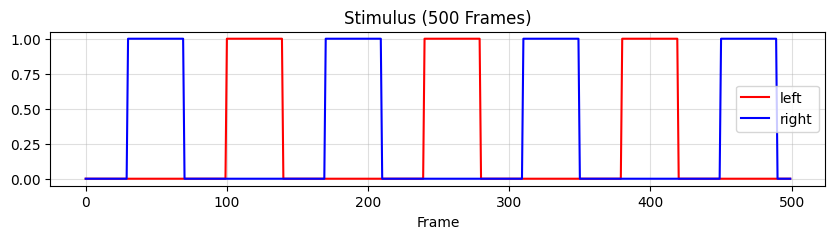

In [82]:
#Visualize the stimulus signal for first 500 frames
plt.figure(figsize=(10,2))
plt.plot(stimulus_left[:500],c = "red")
plt.plot(stimulus_right[:500],c = "blue")
plt.xlabel("Frame")
plt.grid(alpha = 0.4)
plt.title("Stimulus (500 Frames)")
plt.legend(["left", "right"])
plt.show()

![Stimulus diagram](../images/stimulus.png)

**Figure:** Schematic representation of the phototaxis stimulation provided to the fish.
Dark blocks indicate a half-field dark stimulus on the corresponding side.

The stimulus paradigm is **periodic**, consisting of repeated **cycles** of **140 frames** each.
Within each cycle, the fish experienced two phototaxis stimuli, each lasting **40 frames**:
- a **right-sided stimulus** from **Frame 30–70**, and
- a **left-sided stimulus** from **Frame 100–140**.

From this paradigm, we define the following criteria for identifying **stimulus-locked neurons**:
- The neuron’s activity contains a periodic component with a **wavelength of 140 frames** (equivalently, a **frequency of 1/140 Hz**) that matches the stimulus periodicity.
- The neuron’s activity contains a periodic component whose **phase** aligns with the stimulus presentation windows, i.e., **Frame 30–70** (right) or **Frame 100–140** (left).



# Step 2: Identification of sensory neurons by Fourier Transformation

Now, we would like to perform **Discrete Fourier Transformation** on the neuron activity data and select neurons that match with the selection criteria we outlined previously.



## Step 2.1: Loading Neuron Activity Data

We begin by loading the **neuron activity data**. The example dataset used in this notebook comes from a **public zebrafish whole-brain calcium imaging dataset**. Specifically, we use **Fish_6**, which is also the example shown in the figures of the [original Neuron paper](<https://www.cell.com/neuron/pdf/S0896-6273%2818%2930844-4.pdf>).

This dataset contains activity traces from approximately **100,000 neurons** recorded over **~4,000 frames** at a sampling rate of **1.97 Hz**. Each trace represents the standardized **z-scored ΔF/F fluorescence signal** of an individual neuron.

Due to the file size, please download the raw data **'CellRespZ.h5'** (~1.3GB) by running the following code cell. Or download it manually from [google drive](<https://drive.google.com/file/d/11j_hQXRwY7URa9UnZYo6vAYR5TWLgHGj/view?usp=sharing>) and put it in the `/data/` folder under the project folder.



In [83]:
import gdown
dest_file = DATA_DIR / "CellRespZ.h5"

# Google Drive link
url = "https://drive.google.com/uc?export=download&id=11j_hQXRwY7URa9UnZYo6vAYR5TWLgHGj"

# Check if file already exists
if dest_file.exists():
    print(f"✅ Found dataset at {dest_file}, skipping download.")
else:
    print(f"⬇️ Downloading dataset to {dest_file} ...")
    gdown.download(url, str(dest_file), quiet=False)
    print("✅ Download complete!")

✅ Found dataset at D:\PycharmProjects\Fourier\data\CellRespZ.h5, skipping download.


Run the following code cell to load the neuron activity data, as well as the corresponding coordinate data.

In [84]:
with h5py.File(DATA_DIR / "CellRespZ.h5", 'r') as f:
    # Access the dataset 'CellRespZ'
    cell_resp_z = f['CellRespZ'][()]

#Read the corresponding position index
absIX = pd.read_excel(DATA_DIR /"absIX.xlsx")
absIX = absIX["neuron_index"].to_numpy().T

data = pd.read_excel(
    DATA_DIR / "CellXYZnorm.xlsx",
    header=None
).to_numpy()

coordinate = [data[i] for i in absIX]

print(f'The shape of loaded data is {cell_resp_z.shape},The correct shape is (92538,3780).')

The shape of loaded data is (92538, 3780),The correct shape is (92538,3780).


To make neuron indexing easier, we add a column which encodes each neuron's original index within the dataset in cell response z-score and coordinates.

Before indexing, we check the shape of neuron activity data to see if the data are loaded correctly. The neuron activity data should be an array shape (92538,3780)

Run the following code cell to add the indexing column.

In [85]:
#Add index column for each data
cell_resp_z = [[i, x] for i, x in enumerate(cell_resp_z)]
coordinate = [[i, x] for i, x in enumerate(coordinate)]

Now the neuron activity data is ready, try map a neuron trace.

Run the following code cell to map the activity of a random neuron in first 500 frames

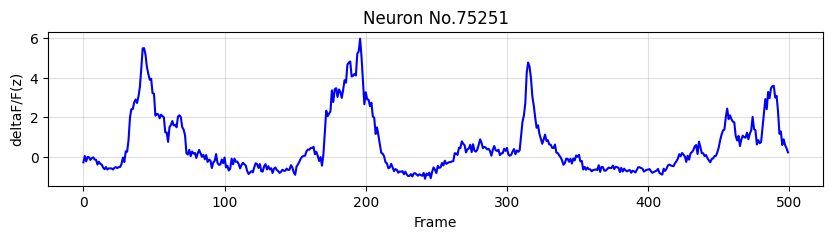

In [88]:
#Visualize a random neuron activity for the first 500 frames
import random
index = random.randint(0, 92538)
plt.figure(figsize=(10,2))
plt.title(f"Neuron No.{index}")
plt.grid(alpha = 0.4)
plt.plot(cell_resp_z[index][1][:500],c = "blue")
plt.xlabel("Frame")
plt.ylabel("deltaF/F(z)")
plt.show()

## Step 2.2: Example Case — Extracting Periodic Neural Activity via Fourier Transformation

In this section, we begin the analysis pipeline by extracting **periodic components** from the neural activity data, focusing on neurons whose activity patterns resemble the **periodic structure of the stimulus**.

The rationale is straightforward: neurons involved in processing the stimulus are expected to exhibit activity patterns that reflect the same periodic timing as the input stimulus.

To identify such neurons, we apply **Fourier transformation** to each neuron’s activity trace, allowing us to quantify key signal properties such as **frequency, wavelength, phase,** and **amplitude**. These features will later serve as classification criteria for identifying **stimulus-locked neurons**.

Before analyzing the entire dataset, we will first demonstrate the procedure on a single example neuron. Specifically, we will perform a Fourier transformation on **Neuron No. 25881** — a representative neuron showing strong periodic activity.

Run the following code block to visualize its activity trace over the first **500 frames**.

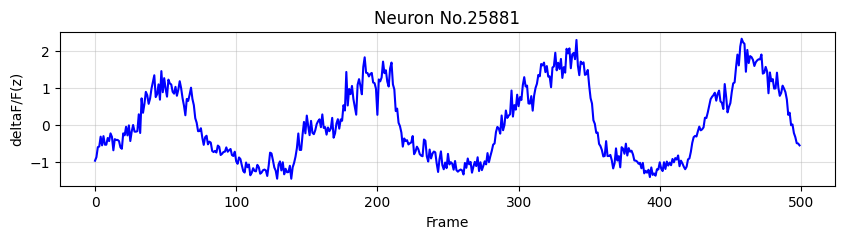

In [87]:
#Visualize neuron activity for the first 500 frames
plt.figure(figsize=(10,2))
plt.title(f"Neuron No.25881")
plt.plot(cell_resp_z[25881][1][:500],c = "blue")
plt.xlabel("Frame")
plt.ylabel("deltaF/F(z)")
plt.grid(alpha=0.4)
plt.show()

As the graph shows, the activity of the selected neuron is **highly periodic**.

Next, we will apply a **Fourier transform** to extract key properties of this periodic component: **frequency (wavelength), amplitude,** and **phase**.

Recall that the Fourier transform decomposes the signal into a sum of sinusoidal components at different frequencies. From these components, we will **select the one whose frequency matches the stimulus** and treat it as the **stimulus-locked component**.

Run the following code cell to perform the Fourier transform and identify the key properties of the stimulus-locked activity.


In [89]:
from demo_functions import check_phase, check_frequency, check_amplitude, check_wavelength

# --- Parameters
stimulus_wavelength = 140
stimulus_frequency = 1 / stimulus_wavelength

# --- Data
activity = cell_resp_z[25881][1]

# --- Compute frequencies once
freqs = check_frequency(activity)
stim_locked_idx = np.where(np.isclose(freqs, stimulus_frequency, rtol=1e-3))[0]

if stim_locked_idx.size == 0:
    print("❌ Stimulus frequency not found in this neuron’s activity.")
else:
    idx = stim_locked_idx[0].item()   # safe scalar extraction

    wavelength = check_wavelength(activity)[idx]
    phase = check_phase(activity)[idx]
    amplitude = check_amplitude(activity)[idx]

    print(f"✅ Frequency match found at index {idx}")
    print(f"Frequency: {freqs[idx]:.6f}")
    print(f"Wavelength: {wavelength}")
    print(f"Phase: {phase}")
    print(f"Amplitude: {amplitude}")


✅ Frequency match found at index 0
Frequency: 0.007143
Wavelength: 140
Phase: 47.12955064424665
Amplitude: 1.2906862497329712


From the output above, we identified the following properties of the **stimulus-locked component** in the neuron's activity data:

- **Frequency:** 0.007143 Hz
- **Wavelength:** 140 frames
- **Phase:** 47.13 frames
- **Amplitude:** 1.291

Using these parameters, we can reconstruct a **simulated signal** that represents the periodic component of the neuron’s response aligned with the stimulus.

Run the following code block to visualize this simulated signal (**red**) overlaid on the raw neural activity (**blue**) for the first **500 frames**.


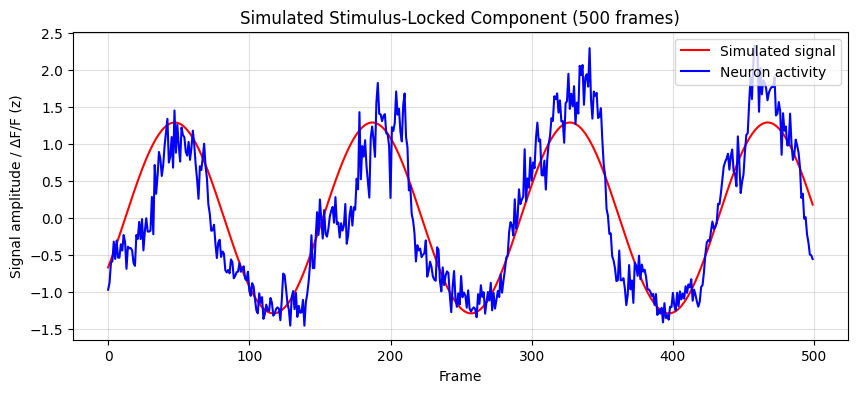

In [91]:
frequency = 0.007143   # Hz (1/140)
wavelength = 140       # frames per cycle
phase = 47.1296        # in frames
amplitude = 1.291
num_frames = 500

# Generate time axis (in frames)
frames = np.arange(num_frames)

# Construct simulated periodic signal
sim_signal = amplitude * np.cos(2 * np.pi * frequency * (frames-phase))

# Plot
plt.figure(figsize=(10, 4))
# Simulated signal
plt.plot(frames, sim_signal, color='red', label='Simulated signal')
# Original neuron activity (first 500 frames)
plt.plot(cell_resp_z[25881][1][:500], color='blue', label='Neuron activity')
plt.title("Simulated Stimulus-Locked Component (500 frames)")
plt.xlabel("Frame")
plt.ylabel("Signal amplitude / ΔF/F (z)")
plt.grid(alpha=0.4)
plt.legend(loc='upper right')
plt.show()

It is important to note that only in rare cases can a neuron's activity be accurately represented by a **single sinusoidal function**.

However, the component that precisely matches the **stimulus frequency** can still serve as a useful approximation of the **stimulus-locked activity** — the portion of the neural signal that reflects the input stimulus.

Not all neurons exhibit such a component in their activity traces. In the next step, we will **filter out neurons** that do not contain a frequency component matching the stimulus periodicity.


## Step 2.3: Identifing Stimulus-Locked Neurons from Fourier Results

We now filter the dataset by checking whether each neuron’s activity contains a **periodic component** whose **frequency matches the stimulus**.

Because we target a fixed frequency (here **1/140 Hz**), we also extract the **phase** and **amplitude** **at that frequency** for downstream classification (Step 3).

> **Note:** Due to floating-point precision, we match frequency using a small tolerance (e.g., `np.isclose(..., rtol=1e-3)`), not exact equality.

Run the following code cell to (1) identify neurons with a component at the stimulus frequency and (2) extract the corresponding **phase** and **amplitude**. *This may take several minutes.*


In [92]:
from demo_functions import check_phase, check_frequency, check_amplitude, check_wavelength
import numpy as np
import time

# --- Parameters
stimulus_wavelength = 140
stimulus_frequency = 1 / stimulus_wavelength

# --- Results storage
n_neurons = len(cell_resp_z)
stim_locked_neuronId = []
stim_locked_amplitude = []
stim_locked_phase = []

# --- Progress setup

print(f"Starting Fourier analysis for {n_neurons} neurons...")
print("This may take several minutes depending on dataset size.\n")

# --- Main loop
for idx, (neuron_id, activity) in enumerate(cell_resp_z):

    # Compute frequency spectrum
    freqs = check_frequency(activity)

    # Find if stimulus frequency exists in spectrum
    stim_locked_idx = np.where(np.isclose(freqs, stimulus_frequency, rtol=1e-3))[0]

    # If found → record neuron info
    if stim_locked_idx.size > 0:
        k = stim_locked_idx[0].item()
        stim_locked_neuronId.append(neuron_id)
        stim_locked_amplitude.append(check_amplitude(activity)[k])
        stim_locked_phase.append(check_phase(activity)[k])

    # Manual progress print every 1000 neurons
    if (idx + 1) % 1000 == 0 or (idx + 1) == n_neurons:
        pct = (idx + 1) / n_neurons * 100
        print(f"Processed {idx + 1}/{n_neurons} neurons ({pct:.1f}%)")

print(f"\n✅ Analysis complete! Found {len(stim_locked_neuronId)} stimulus-locked neurons. ({100*len(stim_locked_neuronId)/len(cell_resp_z):.1f}%)")
stim_locked_neuron = np.column_stack((
    np.array(stim_locked_neuronId, dtype=int),
    np.array(stim_locked_amplitude, dtype=float),
    np.array(stim_locked_phase, dtype=float)
))


Starting Fourier analysis for 92538 neurons...
This may take several minutes depending on dataset size.

Processed 1000/92538 neurons (1.1%)
Processed 2000/92538 neurons (2.2%)
Processed 3000/92538 neurons (3.2%)
Processed 4000/92538 neurons (4.3%)
Processed 5000/92538 neurons (5.4%)
Processed 6000/92538 neurons (6.5%)
Processed 7000/92538 neurons (7.6%)
Processed 8000/92538 neurons (8.6%)
Processed 9000/92538 neurons (9.7%)
Processed 10000/92538 neurons (10.8%)
Processed 11000/92538 neurons (11.9%)
Processed 12000/92538 neurons (13.0%)
Processed 13000/92538 neurons (14.0%)
Processed 14000/92538 neurons (15.1%)
Processed 15000/92538 neurons (16.2%)
Processed 16000/92538 neurons (17.3%)
Processed 17000/92538 neurons (18.4%)
Processed 18000/92538 neurons (19.5%)
Processed 19000/92538 neurons (20.5%)
Processed 20000/92538 neurons (21.6%)
Processed 21000/92538 neurons (22.7%)
Processed 22000/92538 neurons (23.8%)
Processed 23000/92538 neurons (24.9%)
Processed 24000/92538 neurons (25.9%)
P

After filtering, **66,789 neurons** were identified as having a periodic component that matches the **stimulus frequency**.

This step alone provides limited insight into the underlying computation: the set is still too large (over 70% of the original dataset) to interpret meaningfully.

To highlight neurons most likely involved in **stimulus processing**, we will apply additional criteria in the next step—e.g., **phase alignment** with stimulus windows (Frames **30–70** or **100–140**) and **amplitude** thresholds at the stimulus frequency—to prioritize the most strongly stimulus-locked neurons.


## Step 3: Selecting Stimulus-Locked Neurons Based on Phase and Amplitude

In this step, we further refine the group of **stimulus-locked neurons** identified earlier by examining two key properties of their periodic components: **phase** and **amplitude**.

Because we are interested in neurons that are **strongly correlated with the stimulus signal**, two conditions must be met:
1. The neuron must exhibit **strong periodic activity** (high amplitude).
2. The neuron’s activity must be **synchronized in time** with the stimulus presentation (phase alignment).

These two pieces of information are captured in the neuron's **amplitude** and **phase** values extracted from its Fourier component at the stimulus frequency.

Before applying selection thresholds, we first visualize the overall distribution of neurons in the **Amplitude–Phase domain** to observe how these properties vary across the population.

Run the following code cell to plot all stimulus-locked neurons in the amplitude–phase plane.


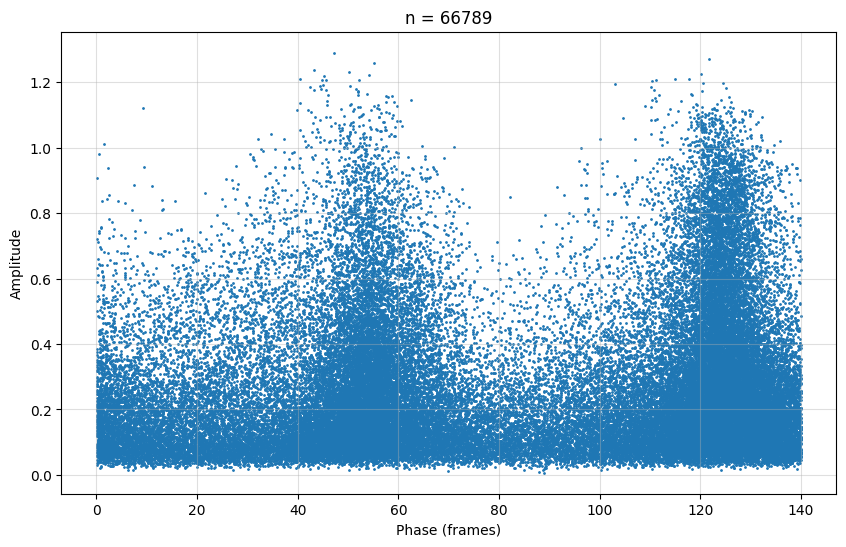

In [93]:
#plot
plt.figure(figsize = (10,6))
plt.grid(alpha=0.4)
plt.scatter(stim_locked_phase,stim_locked_amplitude,s = 1)
plt.xlabel('Phase (frames)')
plt.ylabel('Amplitude')
plt.title(f'n = {len(stim_locked_neuron)}')
plt.show()

To help us design a selection criterion for identifying the most significant group of neurons in the Amplitude–Phase plot,
we first examine how neurons are distributed along each dimension individually.

Here, we visualize the **frequency distribution** (i.e., the number of occurrences) of neurons across the **amplitude** dimensions. This helps reveal typical ranges, density peaks, and potential cutoff points for defining high-amplitude populations

Run the following code cells to visualize the distributions of amplitude among all stimulus-locked neurons.


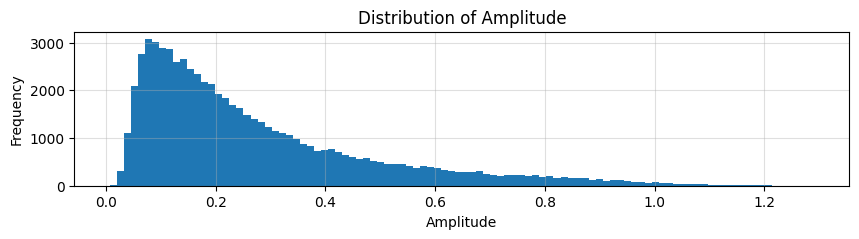

In [94]:
plt.figure(figsize = (10,2))
plt.title("Distribution of Amplitude")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.hist(stim_locked_amplitude,bins = 100)
plt.grid(alpha=0.4)
plt.show()

### Step 3.1: Selection Criterion 1 — Amplitude Threshold

The first selection criterion is based on an **amplitude threshold**.

Because we are interested in neurons that exhibit the **strongest activity**, we retain only the top *k%* of neurons with the highest amplitudes.

Here, **k** is an adjustable cutoff that reflects the desired balance between **significance** and **completeness** of the analysis:
- Increasing *k* (stricter cutoff) prioritizes significance by excluding neurons with weak activity, but may reduce the completeness of the identified population.
- Decreasing *k* (looser cutoff) includes more neurons, but risks incorporating weakly stimulus-related signals.

In this analysis, we set **k = 10**, selecting the **top 10% of neurons** ranked by amplitude. This threshold was also used in the accompanying manuscript.

Run the following code cell to apply the amplitude cutoff and visualize the resulting subset of neurons in the **Amplitude–Phase plane**.


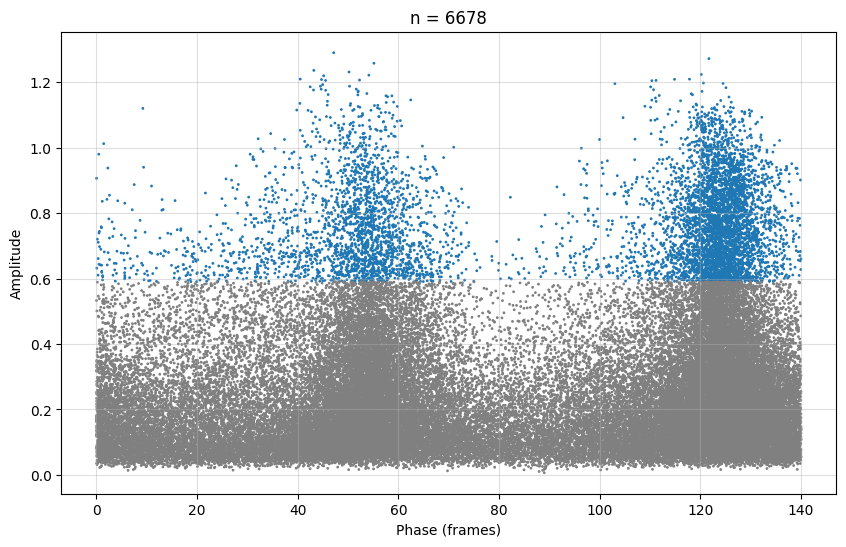

In [95]:
# Step 1 — Parameter
k = 10 #cutoff
cutoff = k/100

# Step 2 — Sort by amplitude (descending)
stim_sorted = stim_locked_neuron[np.argsort(stim_locked_neuron[:, 1])[::-1]]

# Step 3 — Determine how many are in the top 10%
n_total = len(stim_sorted)
n_top = int(n_total * cutoff)  # 10%

# Step 4 — Get the IDs of top 10% neurons
top_neurons = stim_sorted[:n_top, 0].astype(int)

# Step 5 — Create a binary selection vector (1 if selected, else 0)
selection_mask = [1] * n_top + [0] * (n_total-n_top)

# Step 6 — Create auxiliary variables for visualization
colors = ['tab:blue' if x == 1 else 'grey' for x in selection_mask]
sorted_phase = stim_sorted[:, 2]
sorted_amplitude = stim_sorted[:, 1]

# Plot
plt.figure(figsize = (10,6))
plt.grid(alpha=0.4)
plt.scatter(sorted_phase,sorted_amplitude,s = 1, color = colors)
plt.xlabel('Phase (frames)')
plt.ylabel('Amplitude')
plt.title(f'n = {n_top}')
plt.show()


The plot above shows the result of applying a 10% amplitude cutoff.

Neurons colored in **blue** represent those retained after the cutoff, while **gray** neurons were excluded. Conceptually, the amplitude threshold acts as a **horizontal divider**, selecting only neurons with strong periodic activity.

### Step 3.2: Selection Criterion 2 — Phase Constraint

Next, we further refine this subset by applying a **phase constraint**.

The **phase** represents the temporal offset of a neuron’s activity cycle — that is, the point in time within each periodic cycle at which the neuron’s activity reaches its peak. Intuitively, if we approximate a neuron’s activity using a sinusoidal function, the phase corresponds to the **time position of the activity maximum** within each stimulus cycle.

Before applying any cutoff, it is helpful to first examine the **distribution of phase values** across all stimulus-locked neurons.  This allows us to observe whether neurons tend to cluster around specific time windows that correspond to the stimulus presentation periods, and how strongly the stimulus timing influences the overall phase distribution.

Run the following code cell to visualize the frequency distribution of phase among all stimulus-locked neurons.


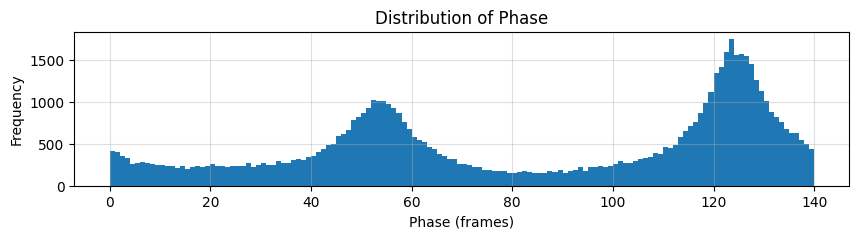

In [96]:
plt.figure(figsize = (10,2))
plt.title("Distribution of Phase")
plt.xlabel("Phase (frames)")
plt.ylabel("Frequency")
plt.hist(stim_locked_phase,bins = 140)
plt.grid(alpha=0.4)
plt.show()

As shown in the histogram above, the neurons form a **bimodal distribution**, with two prominent peaks centered around **Phase ≈ 50** and **Phase ≈ 120**. These two time points correspond closely to the midpoints of the right- and left-sided stimulus presentation windows, respectively.

This observation suggests that a large proportion of neurons exhibit activity synchronized with the alternating stimulus pattern. To isolate these neurons, we apply a **phase constraint** based on the known timing of the stimulus presentation.

Unlike the amplitude threshold, which is empirically chosen, the phase constraint is **directly defined** by the temporal structure of the stimulus itself.

Specifically, we retain only the neurons whose phase values fall within the two stimulus presentation windows:

- **Right-sided stimulus:** Frames **30–70**
- **Left-sided stimulus:** Frames **100–140**

Run the following code cell to apply the phase constraint and visualize the resulting neurons in the **Amplitude–Phase plane**.


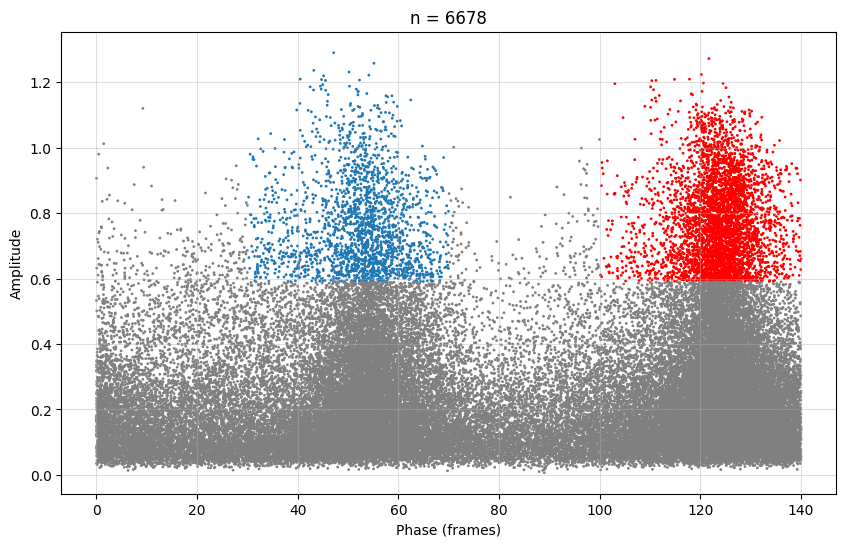

In [98]:
# Parameters
phase = stim_sorted[:, 2]
n_top = int(n_total * cutoff)
n_total = len(stim_sorted)

# Define windows (inclusive)
win_right = (30, 70)
win_left = (100, 140)

# Create selection mask
phase_mask = []
for i in range(n_top):
    if phase[i] >= win_right[0] and phase[i] <= win_right[1]:
        phase_mask.append(1)
    elif phase[i] >= win_left[0] and phase[i] <= win_left[1]:
        phase_mask.append(2)
    else:
        phase_mask.append(0)

phase_mask += (n_total-n_top) * [0]

# Assign neuron by mask
right_stimulus_neuron = stim_sorted[phase_mask == 1]
left_stimulus_neuron = stim_sorted[phase_mask == 2]

# Create auxiliary variables for visualization
colors = ['tab:blue' if x == 1 else 'red' if x == 2 else 'grey' for x in phase_mask]

# Plot
plt.figure(figsize = (10,6))
plt.grid(alpha=0.4)
plt.scatter(sorted_phase,sorted_amplitude,s = 1, color = colors)
plt.xlabel('Phase (frames)')
plt.ylabel('Amplitude')
plt.title(f'n = {n_top}')
plt.show()

Now that we have successfully identified and labeled the significant neurons, each has been assigned according to its corresponding stimulus side.

In the plot above, neurons colored in **blue** are associated with the **right-sided stimulus**, while those in **red** correspond to the **left-sided stimulus**.

Together, these neurons represent the **stimulus-locked population**, whose activity patterns are both strong in amplitude and temporally aligned with the timing of the visual stimulation.
